<a href="https://colab.research.google.com/github/Ayesha-Arooj/Statistical-and-Mathematical-Methods-for-Data-Science-Project/blob/main/Statistical_and_Mathematical_Methods_for_Data_Science__project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Role of AI Tools in Programming Education: A Statistical Analysis of Usage Patterns, Learning Outcomes, and Ethical Perceptions Among University Students

# Introduction

The rapid integration of Artificial Intelligence (AI) tools into academic and professional workflows has fundamentally reshaped how students approach problem-solving, particularly in programming-intensive disciplines. Tools such as AI chatbots and code assistants have become increasingly accessible to students across Data Science, Computer Science, Information Technology, Software Engineering, and Artificial Intelligence programs, raising important questions about their role in learning, skill development, and academic integrity.

This project applies statistical and mathematical methods to examine patterns of AI tool usage among university students in the context of programming assignments. Using survey data collected from 980 students across multiple degree programs and academic levels, the study investigates how frequently and extensively students rely on AI tools, the perceived effects of this reliance on problem-solving ability and confidence, and the broader ethical considerations surrounding AI-assisted coursework.

**Objectives of this study:**
- Quantify the extent and frequency of AI tool usage in solving programming assignments across degree programs and academic levels
- Examine the relationship between AI tool usage and self-reported improvements in problem-solving skills and confidence
- Assess student attitudes toward the ethical acceptability of AI tool use and the need for institutional policy
- Identify statistically significant associations between demographic factors (age, gender, degree program, academic level) and patterns of AI adoption

**Methodology overview:**
The analysis draws on a combination of descriptive statistics and inferential techniques, including:
- **Chi-square tests** to examine associations between categorical variables (e.g., degree program and AI usage frequency)
- **Kruskal-Wallis tests** to compare distributions of ordinal responses across independent groups
- **Spearman's rank correlation** to assess monotonic relationships between ordinal variables (e.g., usage frequency and perceived skill improvement)
- **Logistic regression** to model the likelihood of specific behavioral outcomes (e.g., submitting unmodified AI-generated work) based on predictor variables

By combining these statistical and mathematical methods, this project aims to provide an evidence-based understanding of how AI tools are reshaping the programming education landscape, and to surface insights that can inform both pedagogical practice and institutional policy.

#Importing and Loading the Dataset

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Load data from CSV
file_path = "/content/drive/MyDrive/smm/assesment.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Preview the dataset
print(df.head())

             Timestamp    Age  Gender          Degree Program  \
0  01/04/2024 04:49:41  21-24  Female  Information Technology   
1  01/04/2024 13:48:01  21-24    Male    Software Engineering   
2  01/04/2024 21:06:26  21-24    Male  Information Technology   
3  01/04/2024 23:15:39  21-24    Male    Software Engineering   
4  01/05/2024 00:01:29  25-28    Male  Information Technology   

  What is your current academic level?  \
0                        Undergraduate   
1                        Undergraduate   
2                        Post Graduate   
3                        Undergraduate   
4                        Undergraduate   

  Do you think AI will play a key role in shaping the future of computer science education?  \
0                                                Yes                                          
1                                                Yes                                          
2                                                 No                   

/tmp/ipykernel_4423/2507029297.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


#Dataset Information

In [49]:
df.shape

(980, 27)

In [50]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Degree Program',
       'What is your current academic level?',
       'Do you think AI will play a key role in shaping the future of computer science education?',
       'How often do you read or learn about advancements in AI?',
       'How much time do you typically spend solving a programming assignment?',
       'Have you faced assignments that seemed unsolvable without external help (human or AI)?',
       'What percentage of your programming assignments do you solve with the help of AI tools?',
       'Do AI tools help you discover new approaches or algorithms that you weren't aware of before?',
       'Are there any assignments or tasks where AI tools have not been helpful?',
       'How often do you encounter programming assignments in your coursework?',
       'How would you rate the difficulty of your programming assignments?',
       'Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?',
       'Do yo

#Association Between AI Learning Frequency and Perceptions of AI’s Future Role in Education

In [51]:
from scipy import stats
import pandas as pd

# Actual column names from your DataFrame
belief_col = "Do you think AI will play a key role in shaping the future of computer science education?"
frequency_col = "How often do you read or learn about advancements in AI?"

# Map frequency responses to ordinal ranks
frequency_mapping = {
    "Never": 5,
    "Occasionally": 3,
    "Weekly": 2,
    "Daily": 1
}

df["Learn_Frequency_Rank"] = df[frequency_col].map(frequency_mapping)

# Check how the responses were encoded
print(df[frequency_col].value_counts(dropna=False))

# Create groups based on belief in AI's future role
groups = []

for group in df[belief_col].dropna().unique():
    data = df.loc[
        df[belief_col] == group,
        "Learn_Frequency_Rank"
    ].dropna()

    if len(data) > 0:
        groups.append(data)

        print(f"{group}: n = {len(data)}, median = {data.median()}")

# Kruskal-Wallis test
stat, p_value = stats.kruskal(*groups)

print("\nKruskal-Wallis Test")
print(f"H-statistic = {stat:.4f}")
print(f"p-value = {p_value:.4f}")


How often do you read or learn about advancements in AI?
Occasionally    376
Weekly          315
Daily           231
Never            58
Name: count, dtype: int64
Yes: n = 707, median = 2.0
No: n = 91, median = 2.0
Not Sure: n = 182, median = 2.0

Kruskal-Wallis Test
H-statistic = 4.0431
p-value = 0.1325


#AI Learning Frequency Distribution by Belief in AI’s Future Role in Computer Science Education

<Figure size 1000x600 with 0 Axes>

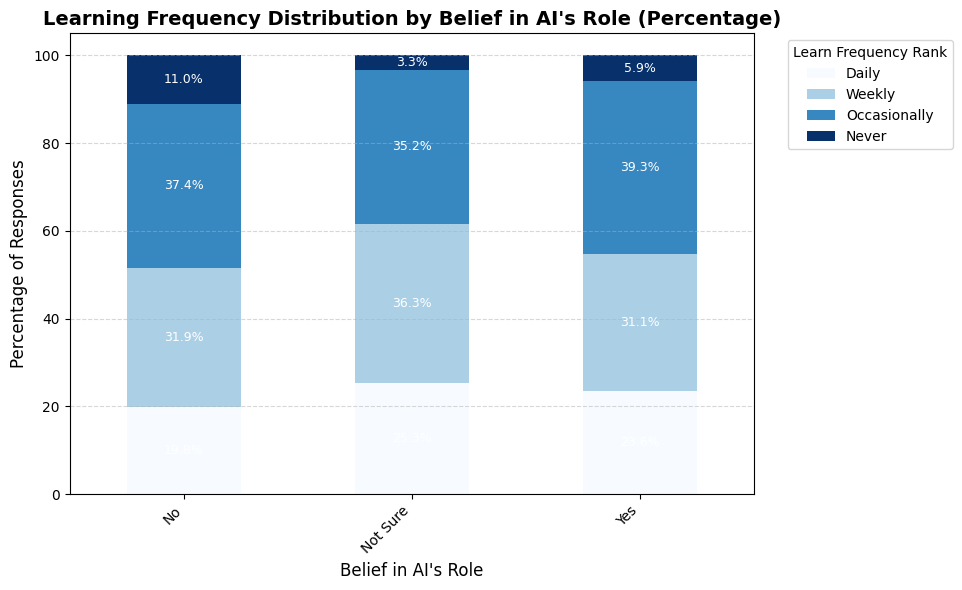

In [52]:
# Calculate the proportion of each category in 'Learn_Frequency_Rank' for each AI belief group
df["Learn_Frequency_Rank"] = df["How often do you read or learn about advancements in AI?"].map(
    {"Daily": 1, "Weekly": 2, "Occasionally": 3, "Never": 4}
)

frequency_counts = pd.crosstab(
    df["Do you think AI will play a key role in shaping the future of computer science education?"],
    df["Learn_Frequency_Rank"]
)

# Convert to percentages
frequency_percentages = frequency_counts.div(frequency_counts.sum(axis=1), axis=0) * 100

# Map rank values back to readable labels, in the order the columns actually appear
rank_to_label = {1: "Daily", 2: "Weekly", 3: "Occasionally", 4: "Never"}
legend_labels = [rank_to_label[r] for r in frequency_percentages.columns]

# Define the refined navy gradient colormap
custom_navy_gradient = plt.cm.Blues

# Plotting the stacked bar chart with the refined navy shades
plt.figure(figsize=(10, 6))
ax = frequency_percentages.plot(
    kind='bar',
    stacked=True,
    colormap=custom_navy_gradient,
    figsize=(10, 6),
    edgecolor=None
)

# Adding percentages on top of each stack
for bar_group in ax.patches:
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"  # White text for clear visibility
        )

# Adding labels and title
plt.title("Learning Frequency Distribution by Belief in AI's Role (Percentage)", fontsize=14, fontweight="bold")
plt.xlabel("Belief in AI's Role", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(
    title="Learn Frequency Rank",
    labels=legend_labels,
    loc='upper right',
    bbox_to_anchor=(1.3, 1),
    fontsize=10
)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [53]:
df["How much time do you typically spend solving a programming assignment?"].unique()

array(['More than 5 hours', 'Less than 2 hours', '2–5 hours'],
      dtype=object)

#Correlation Between Assignment Completion Time and Perceived Programming Assignment Difficulty

In [54]:
time_mapping = {"Less than 2 hours": 1, "2–5 hours": 2, "More than 5 hours": 3}
df["Time_Rank"] = df["How much time do you typically spend solving a programming assignment?"].map(time_mapping)

difficulty_mapping = {"Easy": 1, "Moderate": 2, "Hard": 3}
df["Difficulty_Rank"] = df["How would you rate the difficulty of your programming assignments?"].map(difficulty_mapping)

# 2. Is there a correlation between the time spent on assignments and the perceived difficulty?
if not df["Time_Rank"].isna().any() and not df["Difficulty_Rank"].isna().any():
    correlation, p_value = stats.spearmanr(df["Time_Rank"], df["Difficulty_Rank"])
    print(f"Spearman's Correlation: Rho={correlation}, p-value={p_value}")
    if p_value < 0.05:
        print("Reject the null hypothesis: Significant correlation between time and difficulty.")
    else:
        print("Fail to reject the null hypothesis: No significant correlation.")
else:
    print("Missing data for correlation analysis.")

Spearman's Correlation: Rho=-0.006649799228679628, p-value=0.8353005986163216
Fail to reject the null hypothesis: No significant correlation.


#Perceived Programming Assignment Difficulty by Assignment Completion Time

In [55]:
print(df["Time_Rank"].value_counts())
print(df["Difficulty_Rank"].value_counts())

Time_Rank
2    483
1    270
3    227
Name: count, dtype: int64
Difficulty_Rank
2    597
3    240
1    143
Name: count, dtype: int64


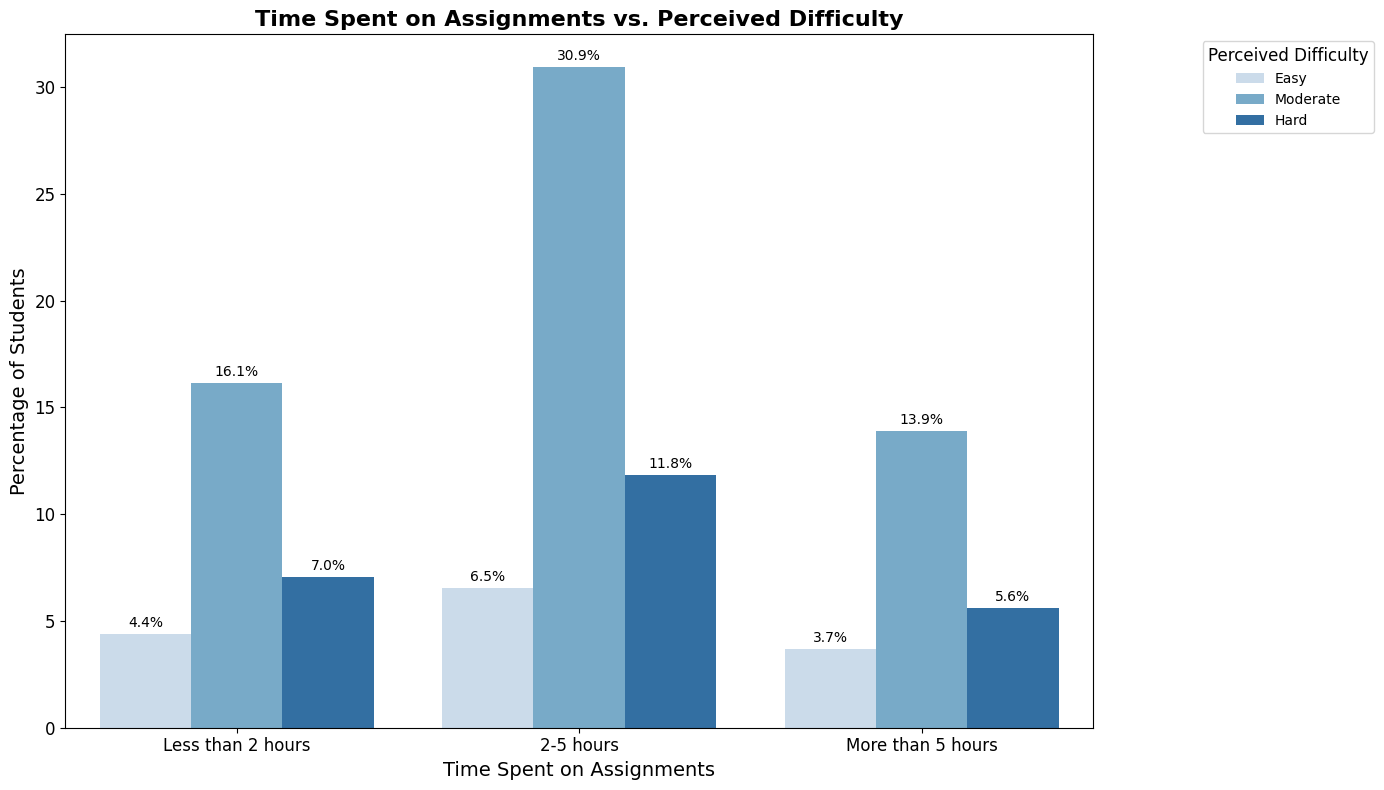

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already defined with the necessary data
time_labels = {1: "Less than 2 hours", 2: "2-5 hours", 3: "More than 5 hours"}
difficulty_labels = {1: "Easy", 2: "Moderate", 3: "Hard"}

# Group data by 'Time_Rank' and 'Difficulty_Rank', then calculate the count
grouped_data = df[["Time_Rank", "Difficulty_Rank"]].dropna().groupby(["Time_Rank", "Difficulty_Rank"]).size().reset_index(name="count")

# Map labels to make the data more interpretable
grouped_data["Time_Label"] = grouped_data["Time_Rank"].map(time_labels)
grouped_data["Difficulty_Label"] = grouped_data["Difficulty_Rank"].map(difficulty_labels)

# Calculate the percentage for each group relative to the total count
total_count = grouped_data["count"].sum()
grouped_data["Percentage"] = (grouped_data["count"] / total_count) * 100

# Standard library colormap instead of custom hex codes
navy_blue_palette = sns.color_palette("Blues", n_colors=grouped_data["Difficulty_Label"].nunique())

# Set up the plot with the new palette
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=grouped_data,
    x="Time_Label",
    y="Percentage",  # Use Percentage instead of count
    hue="Difficulty_Label",
    palette=navy_blue_palette,  # Apply the updated palette
)

# Add text labels (percentage) on top of each bar with some padding
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            # Get label text
            label = f"{height:.1f}%"  # Show only percentage
            # Adjust vertical padding to prevent the text from going out of bounds
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.2,  # Increase padding here if needed
                label,
                ha="center",
                va="bottom",
                color="black",  # Label color to make it visible
                fontsize=10,
            )

# Customize the chart
plt.title("Time Spent on Assignments vs. Perceived Difficulty", fontsize=16, fontweight="bold")
plt.xlabel("Time Spent on Assignments", fontsize=14)
plt.ylabel("Percentage of Students", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust legend placement and styling
plt.legend(
    title="Perceived Difficulty",
    title_fontsize=12,
    loc="upper left",  # Adjusted to upper left
    bbox_to_anchor=(1.1, 1),
)

# Use tight_layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()

# AI Tool Usage Frequency and Its Association with Exploration Beyond the Curriculum (Chi-Square Test)

In [57]:
# 3. Does the use of AI tools inspire students to explore programming concepts beyond their curriculum?
contingency_table = pd.crosstab(
    df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"],
    df["Have AI tools inspired you to explore programming concepts beyond the curriculum?"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Inspiration): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and inspiration.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Inspiration): Chi2=1.350877156258361, p-value=0.8526862578248987
Fail to reject the null hypothesis: No significant association.


# Stacked Distribution of Curriculum Exploration by AI Tool Usage Frequency (Percentage)

<Figure size 1200x600 with 0 Axes>

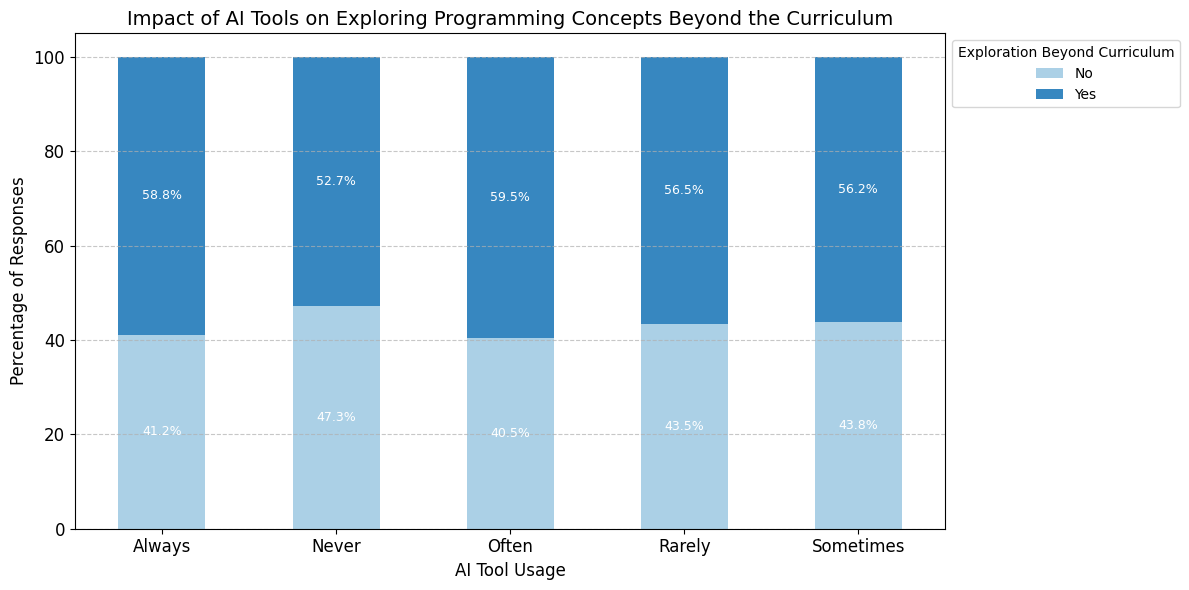

In [58]:
# Calculate the percentage for each cell in the contingency table
contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Standard library colormap instead of custom hex codes, sized to the actual number of categories
custom_palette = sns.color_palette("Blues", n_colors=contingency_percentage.shape[1])

# Plotting the stacked bar chart with the standard palette
plt.figure(figsize=(12, 6))
contingency_percentage.plot(kind='bar', stacked=True, color=custom_palette, figsize=(12, 6))

# Adding percentages on top of each stack
for i, bar_group in enumerate(plt.gca().patches):
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"
        )

# Adding labels and title
plt.title("Impact of AI Tools on Exploring Programming Concepts Beyond the Curriculum", fontsize=14)
plt.xlabel("AI Tool Usage", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Exploration Beyond Curriculum", loc="upper left", bbox_to_anchor=(1, 1))

# Adjust layout to avoid overlap
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

# AI Tool Usage Frequency and Its Association with Perceived Problem-Solving Skill Improvement (Chi-Square Test)

In [59]:
# 4. Do students who use AI tools perceive that these tools improve their problem-solving skills?
contingency_table = pd.crosstab(
    df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"],
    df["Do you think AI tools are improving your problem-solving skills?"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Problem-Solving Skills): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Problem-Solving Skills): Chi2=45.25677033844854, p-value=3.289735337323815e-07
Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.


# AI Tool Usage and Perceived Problem-Solving Skill Improvement: Chi-Square Test and Distribution Analysis

Chi-square Test (Problem-Solving Skills): Chi2=45.25677033844854, p-value=3.289735337323815e-07
Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.


<Figure size 1200x600 with 0 Axes>

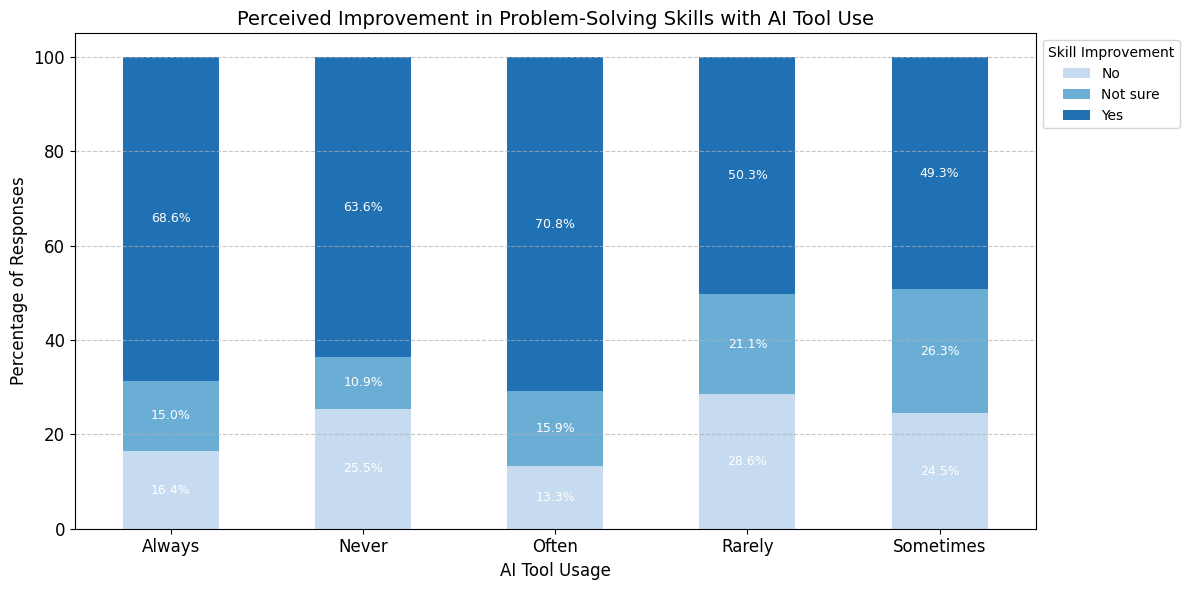

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Assuming 'df' is already loaded with your data

# Creating a contingency table
contingency_table = pd.crosstab(
    df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"],
    df["Do you think AI tools are improving your problem-solving skills?"]
)

# Performing Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Problem-Solving Skills): Chi2={chi2}, p-value={p_value}")

# Displaying whether the null hypothesis is rejected or not
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

# Calculating percentage distribution for plotting
contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Standard library colormap instead of custom hex codes, sized to the actual number of categories
custom_palette = sns.color_palette("Blues", n_colors=contingency_percentage.shape[1])

# Plotting the stacked bar chart with the standard palette
plt.figure(figsize=(12, 6))
contingency_percentage.plot(kind='bar', stacked=True, color=custom_palette, figsize=(12, 6))

# Adding percentages on top of each stack
for bar_group in plt.gca().patches:
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"
        )

# Adding labels and title
plt.title("Perceived Improvement in Problem-Solving Skills with AI Tool Use", fontsize=14)
plt.xlabel("AI Tool Usage", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Skill Improvement", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

# Gender Differences in AI Tool Usage Frequency for Programming Assignments (Kruskal-Wallis Test)

In [61]:
# 5. Are there gender differences in the frequency of AI tool usage for programming assignments?

usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
gender_mapping = {"Male": 1, "Female": 2}

df["Usage_Frequency_Rank"] = df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"].map(usage_mapping)
df["Gender_Rank"] = df["Gender"].map(gender_mapping)

groups = [
    df[df["Gender_Rank"] == group]["Usage_Frequency_Rank"].dropna()
    for group in df["Gender_Rank"].unique()
]
if len(groups) > 1:
    stat, p_value = stats.kruskal(*groups)
    print(f"Kruskal-Wallis Test (Gender Differences): Stat={stat}, p-value={p_value}")
    if p_value < 0.05:
        print("Reject the null hypothesis: Significant difference in AI tool usage frequency by gender.")
    else:
        print("Fail to reject the null hypothesis: No significant difference in usage frequency by gender.")
else:
    print("Insufficient groups for Kruskal-Wallis Test.")

Kruskal-Wallis Test (Gender Differences): Stat=1.7563402692303722, p-value=0.18508165343868566
Fail to reject the null hypothesis: No significant difference in usage frequency by gender.


# Learning Frequency of AI Advancements by Gender

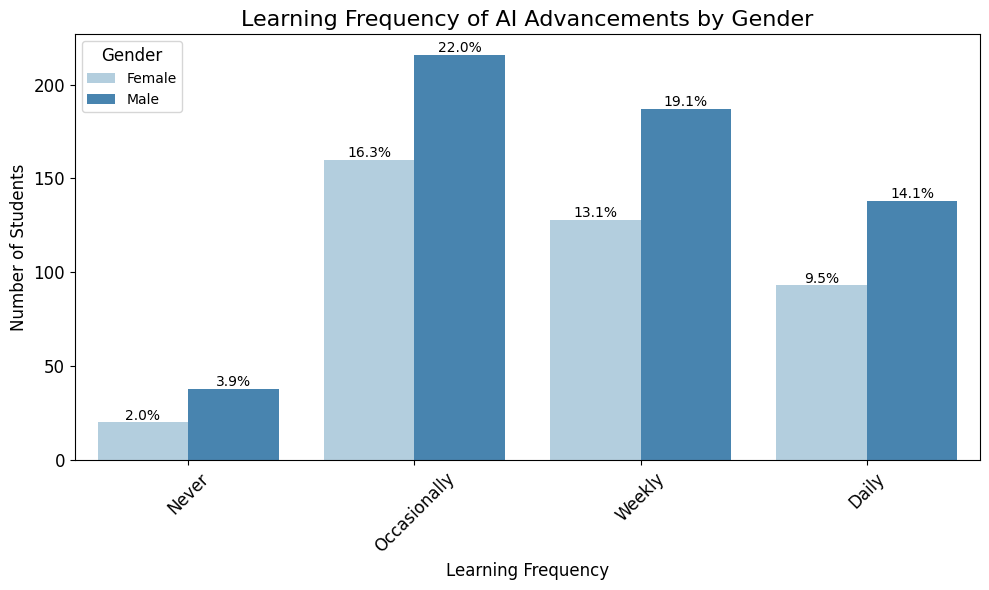

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use the actual survey data instead of the placeholder example DataFrame
learn_freq_col = "How often do you read or learn about advancements in AI?"

# Standard library colormap instead of custom hex codes
navy_palette = sns.color_palette("Blues", n_colors=df["Gender"].nunique())

# Plot the bar chart with hue for gender
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x=learn_freq_col,
    hue="Gender",
    order=["Never", "Occasionally", "Weekly", "Daily"],
    palette=navy_palette
)

# Add percentage labels on top of the bars
total = len(df)  # Total number of data points
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total) * 100
        ax.annotate(f"{percentage:.1f}%",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Customize the chart
plt.title("Learning Frequency of AI Advancements by Gender", fontsize=16)
plt.xlabel("Learning Frequency", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Gender", title_fontsize=12, loc="upper left")

# Adjust layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()

# Primary Use of AI Tools and Its Association with Ethical Acceptability (Chi-Square Test)

In [63]:
# 6. Are students who use AI tools primarily for assistance more likely to consider its use ethically acceptable?
contingency_table = pd.crosstab(
    df["How do you primarily use AI tools for assignments?"],
    df["Do you believe the use of AI tools in assignments is ethically acceptable?"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Ethical Acceptability): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between primary use and ethical acceptability.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Ethical Acceptability): Chi2=1.3199705184131167, p-value=0.5168589533466149
Fail to reject the null hypothesis: No significant association.


# Primary Use of AI Tools and Its Association with Ethical Acceptability: Distribution Analysis

Chi-square Test (Ethical Acceptability): Chi2=1.3199705184131167, p-value=0.5168589533466149
Fail to reject the null hypothesis: No significant association.


<Figure size 1200x600 with 0 Axes>

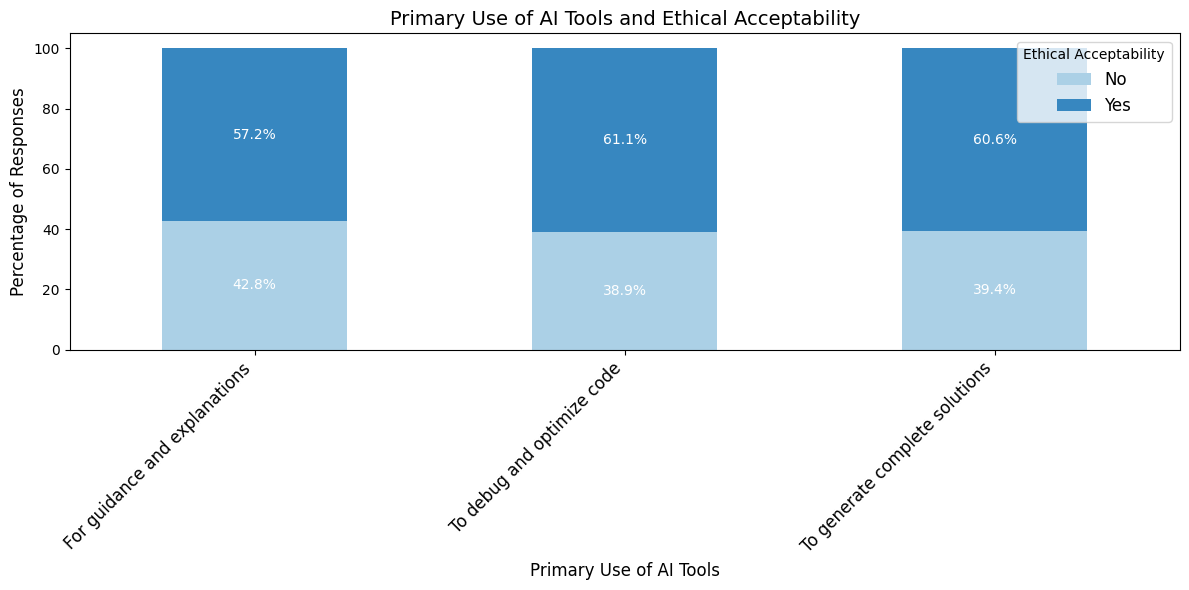

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Contingency table for primary use and ethical acceptability
contingency_table = pd.crosstab(
    df["How do you primarily use AI tools for assignments?"],
    df["Do you believe the use of AI tools in assignments is ethically acceptable?"]
)

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Ethical Acceptability): Chi2={chi2}, p-value={p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between primary use and ethical acceptability.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

# Plotting the stacked bar chart with a standard library color palette
plt.figure(figsize=(12, 6))

contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Standard library colormap instead of custom hex codes, sized to the actual number of categories
custom_palette = sns.color_palette("Blues", n_colors=contingency_percentage.shape[1])
contingency_percentage.plot(kind='bar', stacked=True, figsize=(12, 6), color=custom_palette)

# Adding percentage labels on top of each bar
for i, bar_group in enumerate(plt.gca().patches):
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            color="white"
        )

# Adding title and labels
plt.title("Primary Use of AI Tools and Ethical Acceptability", fontsize=14)
plt.xlabel("Primary Use of AI Tools", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend(title="Ethical Acceptability", labels=contingency_percentage.columns.tolist(), fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

## AI Usage Frequency vs. Perceived Long-Term Impact on Programming Skills

In [65]:
from scipy import stats
import pandas as pd

ai_col = "Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"

impact_col = "Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"

# Create contingency table
table = pd.crosstab(
    df[ai_col],
    df[impact_col]
)

# Put AI-use categories in logical order
table = table.reindex(
    ["Never", "Rarely", "Sometimes", "Often", "Always"]
)

print("Contingency Table:")
print(table)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("\nChi-Square Test")
print(f"Chi-square = {chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p_value:.4f}")


Contingency Table:
Do you think relying heavily on AI tools might negatively affect programming skills in the long run?  No  \
Do you use AI tools (e.g., chatbots, code assis...                                                         
Never                                                                                                 11   
Rarely                                                                                                54   
Sometimes                                                                                             70   
Often                                                                                                 67   
Always                                                                                                66   

Do you think relying heavily on AI tools might negatively affect programming skills in the long run?  Unsure  \
Do you use AI tools (e.g., chatbots, code assis...                                                             


## Distribution of AI-Assisted Programming Usage and Perceived Long-Term Impact


In [66]:
print(
    df["What percentage of your programming assignments do you solve with the help of AI tools?"]
    .value_counts(dropna=False)
)

print("\nNegative impact responses:")
print(
    df["Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"]
    .value_counts(dropna=False)
)


What percentage of your programming assignments do you solve with the help of AI tools?
50–75%           308
25–50%           301
More than 75%    187
Less than 25%    184
Name: count, dtype: int64

Negative impact responses:
Do you think relying heavily on AI tools might negatively affect programming skills in the long run?
Yes       510
No        268
Unsure    202
Name: count, dtype: int64


## Relationship Between AI Usage Frequency and Perceived Long-Term Impact on Programming Skills


In [67]:
import pandas as pd
from scipy import stats

# ============================================================
# Relationship Between AI Usage Frequency and Perceived
# Long-Term Impact on Programming Skills
# ============================================================

usage_column = (
    "Do you use AI tools (e.g., chatbots, code assistants) "
    "to solve programming assignments?"
)

impact_column = (
    "Do you think relying heavily on AI tools might negatively "
    "affect programming skills in the long run?"
)

# Remove missing responses
analysis_df = df[[usage_column, impact_column]].dropna()

# Create contingency table
contingency_table = pd.crosstab(
    analysis_df[usage_column],
    analysis_df[impact_column]
)

print("Contingency Table:")
display(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print(
        "Result: There is a statistically significant association "
        "between AI usage frequency and perceived long-term impact "
        "on programming skills."
    )
else:
    print(
        "Result: There is no statistically significant association "
        "between AI usage frequency and perceived long-term impact "
        "on programming skills."
    )

Contingency Table:


Do you think relying heavily on AI tools might negatively affect programming skills in the long run?,No,Unsure,Yes
"Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?",,,
Always,66,45,115
Never,11,8,36
Often,67,53,144
Rarely,54,32,75
Sometimes,70,64,140



Chi-square statistic: 9.690
Degrees of freedom: 8
p-value: 0.2874
Result: There is no statistically significant association between AI usage frequency and perceived long-term impact on programming skills.


In [68]:
percentage_table = (
    contingency_table
    .div(contingency_table.sum(axis=1), axis=0)
    * 100
)

print("\nRow-wise Percentage Distribution:")
display(percentage_table.round(2))


Row-wise Percentage Distribution:


Do you think relying heavily on AI tools might negatively affect programming skills in the long run?,No,Unsure,Yes
"Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?",,,
Always,29.20,19.91,50.88
Never,20.00,14.55,65.45
Often,25.38,20.08,54.55
Rarely,33.54,19.88,46.58
Sometimes,25.55,23.36,51.09


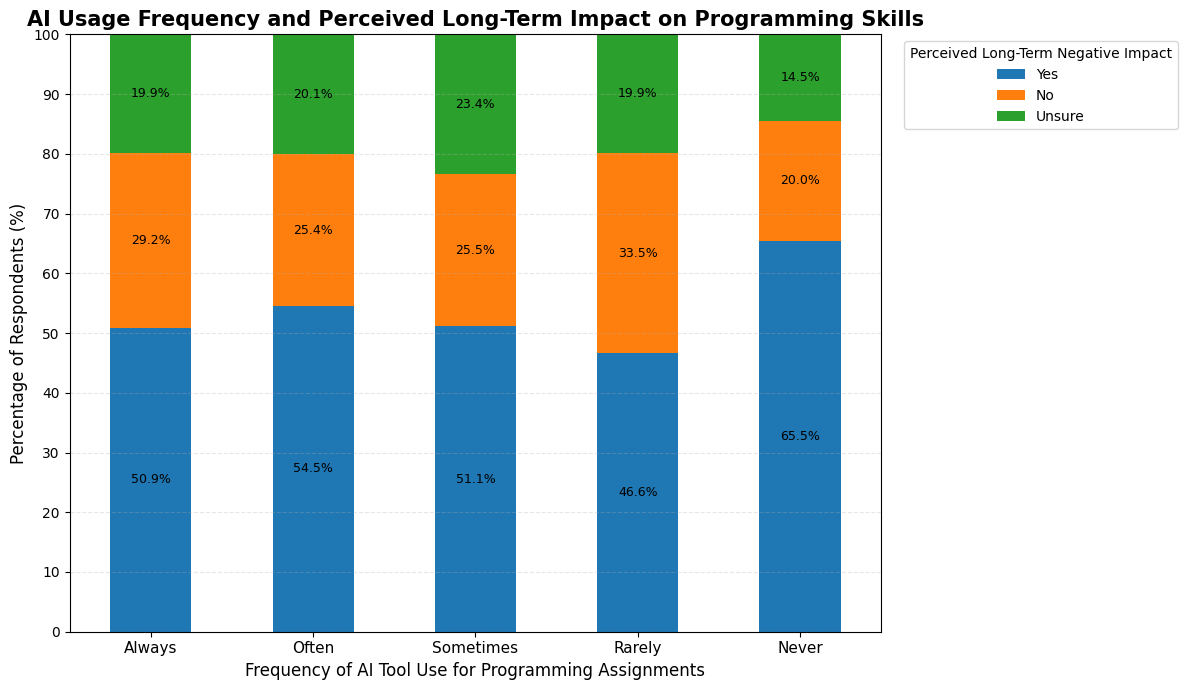

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Relationship Between AI Usage Frequency and Perceived
# Long-Term Impact on Programming Skills
# ============================================================

usage_column = (
    "Do you use AI tools (e.g., chatbots, code assistants) "
    "to solve programming assignments?"
)

impact_column = (
    "Do you think relying heavily on AI tools might negatively "
    "affect programming skills in the long run?"
)

# Keep valid responses
analysis_df = df[[usage_column, impact_column]].dropna()

# Desired order
usage_order = ["Always", "Often", "Sometimes", "Rarely", "Never"]
impact_order = ["Yes", "No", "Unsure"]

# Create percentage table
percentage_table = pd.crosstab(
    analysis_df[usage_column],
    analysis_df[impact_column],
    normalize="index"
) * 100

# Ensure all categories exist and are in the correct order
percentage_table = percentage_table.reindex(
    index=usage_order,
    columns=impact_order,
    fill_value=0
)

# ============================================================
# Create 100% stacked bar chart
# ============================================================

ax = percentage_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

# Add percentage labels
for container in ax.containers:
    labels = []

    for bar in container:
        height = bar.get_height()

        if height >= 3:
            labels.append(f"{height:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Titles and labels
plt.title(
    "AI Usage Frequency and Perceived Long-Term Impact on Programming Skills",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Frequency of AI Tool Use for Programming Assignments",
    fontsize=12
)

plt.ylabel(
    "Percentage of Respondents (%)",
    fontsize=12
)

# Axis formatting
plt.xticks(rotation=0, fontsize=11)
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)

# Legend
plt.legend(
    title="Perceived Long-Term Negative Impact",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Kruskal-Wallis Analysis of AI Usage Frequency Across Perceived Long-Term Impact Levels


In [70]:
# ============================================================
# Chi-Square Test
# Relationship Between AI Usage Frequency and Perceived
# Long-Term Impact on Programming Skills
# ============================================================

from scipy import stats
import pandas as pd

usage_column = (
    "Do you use AI tools (e.g., chatbots, code assistants) "
    "to solve programming assignments?"
)

impact_column = (
    "Do you think relying heavily on AI tools might negatively "
    "affect programming skills in the long run?"
)

# Remove missing responses
analysis_df = df[[usage_column, impact_column]].dropna()

# Create contingency table
contingency_table = pd.crosstab(
    analysis_df[usage_column],
    analysis_df[impact_column]
)

print("Contingency Table:")
display(contingency_table)

# Perform Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("\nChi-Square Test:")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print(
        "\nResult: There is a statistically significant association "
        "between AI usage frequency and perceived long-term negative "
        "impact on programming skills."
    )
else:
    print(
        "\nResult: There is no statistically significant association "
        "between AI usage frequency and perceived long-term negative "
        "impact on programming skills."
    )

Contingency Table:


Do you think relying heavily on AI tools might negatively affect programming skills in the long run?,No,Unsure,Yes
"Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?",,,
Always,66,45,115
Never,11,8,36
Often,67,53,144
Rarely,54,32,75
Sometimes,70,64,140



Chi-Square Test:
Chi-square statistic: 9.690
Degrees of freedom: 8
p-value: 0.2874

Result: There is no statistically significant association between AI usage frequency and perceived long-term negative impact on programming skills.


## Logistic Regression: AI Usage Frequency and Perceived Long-Term Impact


In [71]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)


           feature       VIF
0            const  1.000000
1  Problem_Solving  1.130425
2       Confidence  1.095146
3         Too_Easy  1.006465
4   AI_Freq_Medium  1.539937
5     AI_Freq_High  1.577231
6   Reliance_Agree  1.003353


#Multivariable Analysis of Students’ Perceptions of the Long-Term Impact of AI Reliance

In [72]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Note: Ensure your raw dataframe is loaded as 'df' before running this script

# ============================================================
# 1. FINAL COMPREHENSIVE CONFIGURATION
# ============================================================
COLUMNS = {
    # Demographics
    "age": "Age",
    "gender": "Gender",
    "academic_level": "What is your current academic level?",

    # General Awareness & Workload
    "ai_future_role": "Do you think AI will play a key role in shaping the future of computer science education?",
    "time_spent": "How much time do you typically spend solving a programming assignment?",
    "unsolvable_faced": "Have you faced assignments that seemed unsolvable without external help (human or AI)?",
    "ai_pct_use": "What percentage of your programming assignments do you solve with the help of AI tools?",
    "difficulty_rating": "How would you rate the difficulty of your programming assignments?",

    # Newly Added Behaviors, Habits & Inspiration
    "ai_freq": "Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?",
    "prob_solve": "Do you think AI tools are improving your problem-solving skills?",
    "confidence": "Do you feel more confident in your programming skills after using AI tools?",
    "too_easy": "Do you feel AI tools make programming too easy, reducing the challenge and excitement of solving problems?",
    "explore_concepts": "Have AI tools inspired you to explore programming concepts beyond the curriculum?",
    "understanding_method": "How do you ensure you understand the code or solution provided by AI tools?",
    "primary_use_mode": "How do you primarily use AI tools for assignments?",

    # Newly Added Ethics & Dependency Items
    "discuss_use": "Do you discuss the use of AI tools for assignments with your instructors or peers?",
    "ethically_acceptable": "Do you believe the use of AI tools in assignments is ethically acceptable?",
    "submitted_unmodified": "Have you ever submitted work generated entirely by AI without modifications?",
    "university_policies": "Should universities have policies on the use of AI tools for assignments?",

    # Focus Scale & Target Outcome
    "reliance": "Are students over-relying on AI tools instead of learning the concepts themselves?",
    "neg_impact": "Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"
}

# Explicit structures for standard scales
RELIANCE_CATEGORIES = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]

# ============================================================
# 2. DEFINITIVE DATA PIPELINE FUNCTION
# ============================================================
def prepare_ultimate_analysis_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes text responses across all survey dimensions, extracts high-signal
    behavioral and ethical variables, and builds the finalized design matrix.
    """
    working_df = df.copy()

    # Uniform text preprocessing across every active column layer
    for col_key, col_name in COLUMNS.items():
        if col_name in working_df.columns:
            working_df[col_name] = (
                working_df[col_name]
                .astype(str)
                .str.strip()
                .str.replace(r"\s+", " ", regex=True)
            )

    # Dynamic target lists for continuous feature stacking
    binary_features = []

    # A. Delineate Target Variable (1=Yes, 0=No/Unsure combined to safeguard binary variation)
    working_df["Target_Negative_Impact"] = working_df[COLUMNS["neg_impact"]].apply(lambda x: 1 if x == "Yes" else 0)

    # B. Pure Binary Mapping Elements (Yes=1, No=0)
    yes_no_map = {"No": 0, "Yes": 1}

    binary_mapping_targets = {
        "Problem_Solving_Yes": "prob_solve",
        "Confidence_Yes": "confidence",
        "Too_Easy_Yes": "too_easy",
        "Unsolvable_Faced_Yes": "unsolvable_faced",
        "Inspired_Beyond_Curriculum": "explore_concepts",
        "Discusses_With_Peers": "discuss_use",
        "Ethically_Acceptable_Yes": "ethically_acceptable",
        "Submitted_Unmodified_Yes": "submitted_unmodified"
    }

    for feature_name, col_key in binary_mapping_targets.items():
        working_df[feature_name] = working_df[COLUMNS[col_key]].map(yes_no_map)
        binary_features.append(feature_name)

    # C. Strategic Categorical & Behavioral Encoding Blocks
    # 1. Demographics (Gender Male=1, Female=0)
    working_df["Gender_Male"] = working_df[COLUMNS["gender"]].map({"Male": 1, "Female": 0})
    binary_features.append("Gender_Male")

    # 2. Strategic Structural Dummies (Dropping the first alphabetically/ordered entry as baseline)
    age_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["age"]], categories=["17-20", "21-24", "25-28", "28 and above"], ordered=True),
        prefix="Age", drop_first=True, dtype=int
    )

    level_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["academic_level"]], categories=["Undergraduate", "Graduate", "Post Graduate"], ordered=True),
        prefix="Level", drop_first=True, dtype=int
    )

    diff_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["difficulty_rating"]], categories=["Easy", "Moderate", "Hard"], ordered=True),
        prefix="Diff", drop_first=True, dtype=int
    )

    pct_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["ai_pct_use"]], categories=["Less than 25%", "25–50%", "50–75%", "More than 75%"], ordered=True),
        prefix="AI_Vol", drop_first=True, dtype=int
    )

    reliance_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["reliance"]], categories=RELIANCE_CATEGORIES, ordered=True),
        prefix="Over_Reliance", drop_first=True, dtype=int
    )

    # 3. Behavioral Workflow Dummies
    # Workflow checks (Reference baseline: 'I directly use it without much modification')
    method_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["understanding_method"]], categories=["I directly use it without much modification", "I study and modify it", "I test it thoroughly"], ordered=True),
        prefix="Study_Method", drop_first=True, dtype=int
    )

    # Primary Use Mode (Reference baseline: 'To generate complete solutions')
    mode_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["primary_use_mode"]], categories=["To generate complete solutions", "For guidance and explanations", "To debug and optimize code"], ordered=True),
        prefix="AI_Use_Mode", drop_first=True, dtype=int
    )

    # University Policies (Reference baseline: 'No, it should be left to students')
    policy_dummies = pd.get_dummies(
        pd.Categorical(working_df[COLUMNS["university_policies"]], categories=["No, it should be left to students", "Yes, flexible guidelines", "Yes, strict policies"], ordered=True),
        prefix="Policy_Need", drop_first=True, dtype=int
    )

    # D. Final Design Matrix Consolidation
    analysis_df = pd.concat([
        working_df[["Target_Negative_Impact"] + binary_features],
        age_dummies,
        level_dummies,
        diff_dummies,
        pct_dummies,
        reliance_dummies,
        method_dummies,
        mode_dummies,
        policy_dummies
    ], axis=1)

    # Drop incomplete profiles and assert absolute floating point integrity
    analysis_df = analysis_df.dropna().astype(float)
    return analysis_df

# ============================================================
# OPTIMIZED SUBSET REGRESSION
# ============================================================
def run_final_significant_regression(analysis_df: pd.DataFrame):
    """
    Trims dead-weight variables to maximize the statistical power
    of the model, isolating the true drivers of sentiment.
    """
    y = analysis_df["Target_Negative_Impact"]

    # Keep only the high-signal variables we discovered in the full test
    significant_features = [
        "Ethically_Acceptable_Yes",
        "Inspired_Beyond_Curriculum",  # Marginally significant (p=0.08)
        "Over_Reliance_Disagree",
        "Over_Reliance_Neutral",
        "Over_Reliance_Agree",
        "Over_Reliance_Strongly agree",
        "AI_Use_Mode_For guidance and explanations"  # Marginally significant (p=0.09)
    ]

    X = analysis_df[significant_features]
    X = sm.add_constant(X)

    # Re-run the clean model
    final_model = sm.Logit(y, X).fit()

    print(f"\n{'='*85}\nFINALIZED HIGH-SIGNAL LOGISTIC REGRESSION\n{'='*85}")
    print(final_model.summary())

    conf = final_model.conf_int()
    results = pd.DataFrame({
        "Coefficient": final_model.params,
        "Odds Ratio": np.exp(final_model.params),
        "p-value": final_model.pvalues,
        "CI Lower": np.exp(conf[0]),
        "CI Upper": np.exp(conf[1])
    })

    print(f"\n{'='*85}\nODDS RATIOS AND 95% CONFIDENCE INTERVALS\n{'='*85}")
    print(results.round(4).to_string())

    print(f"\n{'='*85}\nCLEANED MODEL FIT\n{'='*85}")
    print(f"Pseudo R²:      {final_model.prsquared:.4f}")
    print(f"LLR p-value:    {final_model.llr_pvalue:.4f}")

# ============================================================
# 4. RUN SYSTEM GATEWAY
# ============================================================
if __name__ == "__main__":
    # Execute full workflow via:
    final_matrix = prepare_ultimate_analysis_dataset(df)
    run_final_significant_regression(final_matrix)
    pass


Optimization terminated successfully.
         Current function value: 0.680819
         Iterations 5

FINALIZED HIGH-SIGNAL LOGISTIC REGRESSION
                             Logit Regression Results                             
Dep. Variable:     Target_Negative_Impact   No. Observations:                  792
Model:                              Logit   Df Residuals:                      784
Method:                               MLE   Df Model:                            7
Date:                    Wed, 23 Sep 2026   Pseudo R-squ.:                 0.01648
Time:                            15:19:25   Log-Likelihood:                -539.21
converged:                           True   LL-Null:                       -548.24
Covariance Type:                nonrobust   LLR p-value:                   0.01167
                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [73]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

# Note: Ensure your raw dataframe is loaded as 'df' before running this script

# ============================================================
# 1. COLUMN CONFIGURATION
# ============================================================
COLUMNS = {
    "age": "Age",
    "gender": "Gender",
    "academic_level": "What is your current academic level?",
    "ai_future_role": "Do you think AI will play a key role in shaping the future of computer science education?",
    "time_spent": "How much time do you typically spend solving a programming assignment?",
    "unsolvable_faced": "Have you faced assignments that seemed unsolvable without external help (human or AI)?",
    "ai_pct_use": "What percentage of your programming assignments do you solve with the help of AI tools?",
    "difficulty_rating": "How would you rate the difficulty of your programming assignments?",
    "ai_freq": "Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?",
    "prob_solve": "Do you think AI tools are improving your problem-solving skills?",
    "confidence": "Do you feel more confident in your programming skills after using AI tools?",
    "too_easy": "Do you feel AI tools make programming too easy, reducing the challenge and excitement of solving problems?",
    "explore_concepts": "Have AI tools inspired you to explore programming concepts beyond the curriculum?",
    "understanding_method": "How do you ensure you understand the code or solution provided by AI tools?",
    "primary_use_mode": "How do you primarily use AI tools for assignments?",
    "discuss_use": "Do you discuss the use of AI tools for assignments with your instructors or peers?",
    "ethically_acceptable": "Do you believe the use of AI tools in assignments is ethically acceptable?",
    "submitted_unmodified": "Have you ever submitted work generated entirely by AI without modifications?",
    "university_policies": "Should universities have policies on the use of AI tools for assignments?",
    "reliance": "Are students over-relying on AI tools instead of learning the concepts themselves?",
    "neg_impact": "Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"
}

RELIANCE_ORDER = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
RELIANCE_RANK_MAP = {cat: i + 1 for i, cat in enumerate(RELIANCE_ORDER)}

# Ordinal maps for variables kept as single rank columns instead of dummy sets
DIFFICULTY_RANK_MAP = {"Easy": 1, "Moderate": 2, "Hard": 3}
AI_VOL_RANK_MAP = {"Less than 25%": 1, "25\u201350%": 2, "50\u201375%": 3, "More than 75%": 4}
AGE_RANK_MAP = {"17-20": 1, "21-24": 2, "25-28": 3, "28 and above": 4}
LEVEL_RANK_MAP = {"Undergraduate": 1, "Graduate": 2, "Post Graduate": 3}

# ============================================================
# 2. DATA PIPELINE
# ============================================================
def prepare_analysis_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans text responses, builds binary/ordinal features, and reports how much
    data each mapping step drops due to unmapped ("Not sure"/"Unsure"/NaN) responses.
    """
    working_df = df.copy()

    # Clean whitespace only on non-null string values -- avoids turning real NaN into "nan"
    for col_key, col_name in COLUMNS.items():
        if col_name in working_df.columns:
            working_df[col_name] = working_df[col_name].apply(
                lambda x: " ".join(str(x).split()) if pd.notna(x) else np.nan
            )

    # --- Target variable: fold "No" and "Unsure" together as 0, "Yes" as 1 ---
    working_df["Target_Negative_Impact"] = working_df[COLUMNS["neg_impact"]].map(
        {"Yes": 1, "No": 0, "Unsure": 0}
    )

    # --- Binary Yes/No features: leave true 3-category responses as NaN, don't silently zero them ---
    yes_no_map = {"No": 0, "Yes": 1}
    binary_mapping_targets = {
        "Problem_Solving_Yes": "prob_solve",
        "Confidence_Yes": "confidence",
        "Too_Easy_Yes": "too_easy",
        "Unsolvable_Faced_Yes": "unsolvable_faced",
        "Inspired_Beyond_Curriculum": "explore_concepts",
        "Discusses_With_Peers": "discuss_use",
        "Ethically_Acceptable_Yes": "ethically_acceptable",
        "Submitted_Unmodified_Yes": "submitted_unmodified",
    }

    binary_features = []
    print("--- Missingness report for binary features ---")
    for feature_name, col_key in binary_mapping_targets.items():
        mapped = working_df[COLUMNS[col_key]].map(yes_no_map)
        n_missing = mapped.isna().sum() - working_df[COLUMNS[col_key]].isna().sum()
        if n_missing > 0:
            unmapped_vals = working_df.loc[
                mapped.isna() & working_df[COLUMNS[col_key]].notna(), COLUMNS[col_key]
            ].unique()
            print(f"  {feature_name}: {n_missing} unmapped values -> {unmapped_vals}")
        working_df[feature_name] = mapped
        binary_features.append(feature_name)

    # --- Demographics ---
    working_df["Gender_Male"] = working_df[COLUMNS["gender"]].map({"Male": 1, "Female": 0})
    binary_features.append("Gender_Male")

    # --- Ordinal variables kept as single rank columns (preserves order, saves df, more power) ---
    working_df["Age_Rank"] = working_df[COLUMNS["age"]].map(AGE_RANK_MAP)
    working_df["Level_Rank"] = working_df[COLUMNS["academic_level"]].map(LEVEL_RANK_MAP)
    working_df["Difficulty_Rank"] = working_df[COLUMNS["difficulty_rating"]].map(DIFFICULTY_RANK_MAP)
    working_df["AI_Volume_Rank"] = working_df[COLUMNS["ai_pct_use"]].map(AI_VOL_RANK_MAP)
    working_df["Reliance_Rank"] = working_df[COLUMNS["reliance"]].map(RELIANCE_RANK_MAP)

    ordinal_features = ["Age_Rank", "Level_Rank", "Difficulty_Rank", "AI_Volume_Rank", "Reliance_Rank"]

    # --- Nominal (non-ordered) categorical dummies, with sanitized column names ---
    def make_dummies(col_key, categories, prefix):
        cat_series = pd.Categorical(working_df[COLUMNS[col_key]], categories=categories)
        dummies = pd.get_dummies(cat_series, prefix=prefix, drop_first=True, dtype=int)
        dummies.columns = [c.replace(" ", "_").replace(",", "") for c in dummies.columns]
        return dummies

    method_dummies = make_dummies(
        "understanding_method",
        ["I directly use it without much modification", "I study and modify it", "I test it thoroughly"],
        "Study_Method",
    )
    mode_dummies = make_dummies(
        "primary_use_mode",
        ["To generate complete solutions", "For guidance and explanations", "To debug and optimize code"],
        "AI_Use_Mode",
    )
    policy_dummies = make_dummies(
        "university_policies",
        ["No, it should be left to students", "Yes, flexible guidelines", "Yes, strict policies"],
        "Policy_Need",
    )

    analysis_df = pd.concat(
        [
            working_df[["Target_Negative_Impact"] + binary_features + ordinal_features],
            method_dummies,
            mode_dummies,
            policy_dummies,
        ],
        axis=1,
    )

    n_before = len(analysis_df)
    analysis_df = analysis_df.dropna().astype(float)
    n_after = len(analysis_df)
    print(f"\nRows before dropna: {n_before} | after dropna: {n_after} "
          f"({n_before - n_after} dropped, {(n_before - n_after) / n_before:.1%})")

    return analysis_df


# ============================================================
# 3. MULTICOLLINEARITY CHECK
# ============================================================
def check_vif(X: pd.DataFrame) -> pd.DataFrame:
    """Variance Inflation Factor for each predictor (excluding the constant)."""
    X_no_const = X.drop(columns=["const"], errors="ignore")
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_no_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


# ============================================================
# 4. FULL MODEL (reported honestly -- no post-hoc feature trimming)
# ============================================================
def run_full_model(analysis_df: pd.DataFrame):
    y = analysis_df["Target_Negative_Impact"]
    X = analysis_df.drop(columns=["Target_Negative_Impact"])
    X = sm.add_constant(X)

    print(f"\n{'='*85}\nFULL LOGISTIC REGRESSION (all predictors, reported as-is)\n{'='*85}")
    full_model = sm.Logit(y, X).fit(disp=True)
    print(full_model.summary())

    conf = full_model.conf_int()
    results = pd.DataFrame({
        "Coefficient": full_model.params,
        "Odds Ratio": np.exp(full_model.params),
        "p-value": full_model.pvalues,
        "CI Lower": np.exp(conf[0]),
        "CI Upper": np.exp(conf[1]),
    })
    print(f"\n{'='*85}\nODDS RATIOS AND 95% CONFIDENCE INTERVALS\n{'='*85}")
    print(results.round(4).to_string())

    print(f"\nPseudo R²:   {full_model.prsquared:.4f}")
    print(f"LLR p-value: {full_model.llr_pvalue:.4f}")

    print(f"\n{'='*85}\nVARIANCE INFLATION FACTORS (VIF > 5 suggests problematic collinearity)\n{'='*85}")
    print(check_vif(X).round(2).to_string(index=False))

    return full_model, X, y


# ============================================================
# 5. LASSO-BASED FEATURE SELECTION (principled alternative to manual trimming)
# ============================================================
def run_lasso_selection(X: pd.DataFrame, y: pd.Series):
    X_no_const = X.drop(columns=["const"], errors="ignore")

    lasso_cv = LogisticRegressionCV(
        penalty="l1", solver="liblinear", cv=5, scoring="neg_log_loss",
        Cs=20, max_iter=2000, random_state=42,
    )
    lasso_cv.fit(X_no_const, y)

    coefs = pd.Series(lasso_cv.coef_[0], index=X_no_const.columns)
    selected = coefs[coefs != 0].sort_values(key=abs, ascending=False)

    print(f"\n{'='*85}\nLASSO-SELECTED FEATURES (cross-validated, not p-value fished)\n{'='*85}")
    print(f"Optimal C: {lasso_cv.C_[0]:.4f}")
    print(selected.round(4).to_string())
    print(f"\nFeatures dropped to zero: {list(coefs[coefs == 0].index)}")

    return selected


# ============================================================
# 6. OUT-OF-SAMPLE VALIDATION
# ============================================================
def run_holdout_validation(X: pd.DataFrame, y: pd.Series):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    train_model = sm.Logit(y_train, X_train).fit(disp=False)
    pred_probs = train_model.predict(X_test)
    pred_labels = (pred_probs > 0.5).astype(int)

    auc = roc_auc_score(y_test, pred_probs)

    print(f"\n{'='*85}\nOUT-OF-SAMPLE VALIDATION (20% holdout)\n{'='*85}")
    print(f"Test AUC: {auc:.4f}")
    print(classification_report(y_test, pred_labels, zero_division=0))

    if auc < 0.6:
        print("Note: AUC close to 0.5 indicates the model has limited real-world "
              "predictive power despite statistically significant coefficients -- "
              "treat findings as exploratory/associational, not predictive.")


# ============================================================
# 7. RUN FULL WORKFLOW
# ============================================================
if __name__ == "__main__":
    final_matrix = prepare_analysis_dataset(df)

    full_model, X_full, y_full = run_full_model(final_matrix)
    run_lasso_selection(X_full, y_full)
    run_holdout_validation(X_full, y_full)

--- Missingness report for binary features ---
  Problem_Solving_Yes: 188 unmapped values -> ['Not sure']

Rows before dropna: 980 | after dropna: 792 (188 dropped, 19.2%)

FULL LOGISTIC REGRESSION (all predictors, reported as-is)
Optimization terminated successfully.
         Current function value: 0.673887
         Iterations 4
                             Logit Regression Results                             
Dep. Variable:     Target_Negative_Impact   No. Observations:                  792
Model:                              Logit   Df Residuals:                      771
Method:                               MLE   Df Model:                           20
Date:                    Wed, 23 Sep 2026   Pseudo R-squ.:                 0.02649
Time:                            15:19:25   Log-Likelihood:                -533.72
converged:                           True   LL-Null:                       -548.24
Covariance Type:                nonrobust   LLR p-value:                   0.08682
   

#Differences in Perceived Long-Term Negative Impact Across AI Usage Frequency Groups

In [74]:
from scipy.stats import f_oneway

# ---------------------------------------------------------
# 1. Define mappings
# ---------------------------------------------------------

ai_usage_mapping = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

impact_mapping = {
    "No": 0,
    "Unsure": 1,
    "Yes": 2
}

# ---------------------------------------------------------
# 2. Map questionnaire responses to numerical values
# ---------------------------------------------------------

df["AI_Reliance_Rank"] = (
    df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"]
    .str.strip()
    .map(ai_usage_mapping)
)

df["Negative_Impact_Label"] = (
    df["Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"]
    .str.strip()
    .map(impact_mapping)
)

# ---------------------------------------------------------
# 3. Check whether mapping worked correctly
# ---------------------------------------------------------

print("AI Reliance responses:")
print(df["Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?"]
      .value_counts(dropna=False))

print("\nNegative Impact responses:")
print(df["Do you think relying heavily on AI tools might negatively affect programming skills in the long run?"]
      .value_counts(dropna=False))

# ---------------------------------------------------------
# 4. Remove missing/unmapped responses
# ---------------------------------------------------------

df_clean = df.dropna(
    subset=["AI_Reliance_Rank", "Negative_Impact_Label"]
).copy()

# ---------------------------------------------------------
# 5. Create groups according to AI reliance
# ---------------------------------------------------------

ranks = sorted(df_clean["AI_Reliance_Rank"].unique())

groups = [
    df_clean.loc[
        df_clean["AI_Reliance_Rank"] == rank,
        "Negative_Impact_Label"
    ]
    for rank in ranks
]

# ---------------------------------------------------------
# 6. Display group sizes
# ---------------------------------------------------------

print("\nGroup counts:")

for rank, group in zip(ranks, groups):
    label = {1: "Never", 2: "Rarely", 3: "Sometimes",
             4: "Often", 5: "Always"}[rank]

    print(
        f"AI Reliance = {label} ({rank}): "
        f"{len(group)} respondents"
    )

# ---------------------------------------------------------
# 7. Perform one-way ANOVA
# ---------------------------------------------------------

if len(groups) >= 2:

    # Make sure every group contains observations
    groups = [group for group in groups if len(group) > 0]

    if len(groups) >= 2:

        f_stat, p_value = f_oneway(*groups)

        print("\n--- One-Way ANOVA Results ---")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value: {p_value:.4f}")

        # -------------------------------------------------
        # 8. Interpretation
        # -------------------------------------------------

        alpha = 0.05

        if p_value < alpha:
            print(
                "Result: There is a statistically significant "
                "difference in perceived negative impact across "
                "AI reliance groups (p < 0.05)."
            )
        else:
            print(
                "Result: There is no statistically significant "
                "difference in perceived negative impact across "
                "AI reliance groups (p >= 0.05)."
            )

else:
    print(
        "ANOVA cannot be performed because fewer than "
        "two AI reliance groups are present."
    )


AI Reliance responses:
Do you use AI tools (e.g., chatbots, code assistants) to solve programming assignments?
Sometimes    274
Often        264
Always       226
Rarely       161
Never         55
Name: count, dtype: int64

Negative Impact responses:
Do you think relying heavily on AI tools might negatively affect programming skills in the long run?
Yes       510
No        268
Unsure    202
Name: count, dtype: int64

Group counts:
AI Reliance = Never (1): 55 respondents
AI Reliance = Rarely (2): 161 respondents
AI Reliance = Sometimes (3): 274 respondents
AI Reliance = Often (4): 264 respondents
AI Reliance = Always (5): 226 respondents

--- One-Way ANOVA Results ---
F-statistic: 1.8151
p-value: 0.1237
Result: There is no statistically significant difference in perceived negative impact across AI reliance groups (p >= 0.05).


#Association Between AI Usage Frequency and Perceived Negative Impact on Programming Skills

In [75]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df_clean["AI_Reliance_Rank"],
    df_clean["Negative_Impact_Label"]
)

print("\nContingency Table:")
print(contingency_table)

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test ---")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print(
        "There is a statistically significant association "
        "between AI usage frequency and perceived negative impact."
    )
else:
    print(
        "There is no statistically significant association "
        "between AI usage frequency and perceived negative impact."
    )



Contingency Table:
Negative_Impact_Label   0   1    2
AI_Reliance_Rank                  
1                      11   8   36
2                      54  32   75
3                      70  64  140
4                      67  53  144
5                      66  45  115

--- Chi-Square Test ---
Chi-square statistic: 9.6905
Degrees of freedom: 8
p-value: 0.2874
There is no statistically significant association between AI usage frequency and perceived negative impact.


#Association Between AI Usage Frequency and Perceived Long-Term Impact on Programming Skills

In [76]:
import pandas as pd
from scipy.stats import chi2_contingency

ai_usage_col = (
    "Do you use AI tools (e.g., chatbots, code assistants) "
    "to solve programming assignments?"
)

negative_impact_col = (
    "Do you think relying heavily on AI tools might negatively "
    "affect programming skills in the long run?"
)

analysis_df = df[[ai_usage_col, negative_impact_col]].copy()

for col in [ai_usage_col, negative_impact_col]:
    analysis_df[col] = (
        analysis_df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Keep only Yes/No outcome
analysis_df = analysis_df[
    analysis_df[negative_impact_col].isin(["Yes", "No"])
].dropna()

# Order categories
ai_usage_order = [
    "Always",
    "Often",
    "Sometimes",
    "Rarely",
    "Never"
]

contingency_table = pd.crosstab(
    analysis_df[ai_usage_col],
    analysis_df[negative_impact_col]
)

contingency_table = contingency_table.reindex(
    index=ai_usage_order,
    columns=["Yes", "No"],
    fill_value=0
)

print("=" * 70)
print("CONTINGENCY TABLE")
print("=" * 70)
print(contingency_table)

# Chi-square
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("\n" + "=" * 70)
print("CHI-SQUARE TEST")
print("=" * 70)

print(f"Observations: {len(analysis_df)}")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

# Expected frequencies
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected Frequencies:")
print(expected_table.round(2))

# Result
print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

if p_value < 0.05:
    print(
        "There is a statistically significant association between "
        "AI usage frequency and perceived long-term negative impact."
    )
else:
    print(
        "There is no statistically significant association between "
        "AI usage frequency and perceived long-term negative impact."
    )

CONTINGENCY TABLE
Do you think relying heavily on AI tools might negatively affect programming skills in the long run?  Yes  \
Do you use AI tools (e.g., chatbots, code assis...                                                          
Always                                                                                                115   
Often                                                                                                 144   
Sometimes                                                                                             140   
Rarely                                                                                                 75   
Never                                                                                                  36   

Do you think relying heavily on AI tools might negatively affect programming skills in the long run?  No  
Do you use AI tools (e.g., chatbots, code assis...                                                        
Alwa